In [6]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Annotated
from langchain_core.messages import BaseMessage, HumanMessage
from langchain_openai import ChatOpenAI
from langgraph.graph.message import add_messages
from dotenv import load_dotenv

from langgraph.prebuilt import ToolNode, tools_condition
from langchain_community.tools import DuckDuckGoSearchRun
from langchain_core.tools import tool

import requests
import random
import os

In [7]:
load_dotenv()

True

In [8]:
llm = ChatOpenAI(
    model="openai/gpt-oss-120b",
    base_url="https://api.groq.com/openai/v1",
    api_key=os.getenv("GROQ_API_KEY")
)

In [10]:
!pip install -U ddgs

  Using cached ddgs-9.11.4-py3-none-any.whl.metadata (14 kB)
  Using cached click-8.3.1-py3-none-any.whl.metadata (2.6 kB)
  Using cached primp-1.1.3-cp310-abi3-win_amd64.whl.metadata (6.9 kB)
Using cached ddgs-9.11.4-py3-none-any.whl (43 kB)
Using cached primp-1.1.3-cp310-abi3-win_amd64.whl (3.6 MB)
Using cached click-8.3.1-py3-none-any.whl (108 kB)
   ---------------------------------------- 0.0/4.0 MB ? eta -:--:--
   ---------------------------- ----------- 2.9/4.0 MB 34.6 MB/s eta 0:00:01
   ---------------------------------------- 4.0/4.0 MB 38.8 MB/s  0:00:00

   ---------- ----------------------------- 1/4 [lxml]
   ---------- ----------------------------- 1/4 [lxml]
   -------------------- ------------------- 2/4 [click]
   -------------------- ------------------- 2/4 [click]
   ------------------------------ --------- 3/4 [ddgs]
   ------------------------------ --------- 3/4 [ddgs]
   ---------------------------------------- 4/4 [ddgs]




[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [11]:
# Tools
search_tool = DuckDuckGoSearchRun(region="us-en")

@tool
def calculator(first_num: float, second_num: float, operation: str) -> dict:
    """
    Perform a basic arithmetic operation on two numbers.
    Supported operations: add, sub, mul, div
    """
    try:
        if operation == "add":
            result = first_num + second_num
        elif operation == "sub":
            result = first_num - second_num
        elif operation == "mul":
            result = first_num * second_num
        elif operation == "div":
            if second_num == 0:
                return {"error": "Division by zero is not allowed"}
            result = first_num / second_num
        else:
            return {"error": f"Unsupported operation '{operation}'"}
        
        return {"first_num": first_num, "second_num": second_num, "operation": operation, "result": result}
    except Exception as e:
        return {"error": str(e)}


@tool
def get_stock_price(symbol: str) -> dict:
    """
    Fetch latest stock price for a given symbol (e.g. 'AAPL', 'TSLA') 
    using Alpha Vantage with API key in the URL.
    """
    url = f"https://www.alphavantage.co/query?function=GLOBAL_QUOTE&symbol={symbol}&apikey=21M921AWTEFRLFHK"
    r = requests.get(url)
    return r.json()

In [12]:
tools = [get_stock_price, search_tool, calculator]

llm_with_tools = llm.bind_tools(tools)

In [13]:
# state
class ChatState(TypedDict):
    messages: Annotated[list[BaseMessage], add_messages]

In [14]:
# graph nodes
def chat_node(state: ChatState):
    """LLM node that may answer or request a tool call."""
    messages = state['messages']
    response = llm_with_tools.invoke(messages)
    return {"messages": [response]}

tool_node = ToolNode(tools)  # Executes tool calls

In [15]:
# graph structure
graph = StateGraph(ChatState)
graph.add_node("chat_node", chat_node)
graph.add_node("tools", tool_node)

In [16]:
graph.add_edge(START, "chat_node")

# If the LLM asked for a tool, go to ToolNode; else finish
graph.add_conditional_edges("chat_node", tools_condition)

graph.add_edge("tools", "chat_node")

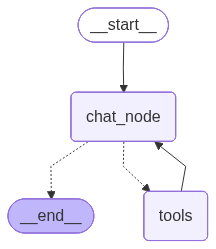

In [17]:
chatbot = graph.compile()

chatbot

In [18]:
# Regular chat
out = chatbot.invoke({"messages": [HumanMessage(content="Hello!")]})

print(out["messages"][-1].content)

Hello! How can I assist you today?


In [19]:
# Chat requiring tool
out = chatbot.invoke({"messages": [HumanMessage(content="What is 2*3?")]})
print(out["messages"][-1].content)

2 × 3 = 6.


In [20]:
# Chat requiring tool
out = chatbot.invoke({"messages": [HumanMessage(content="What is the stock price of apple")]})
print(out["messages"][-1].content)

Apple (AAPL) is currently trading at **$252.82** per share.

* Latest trading day: 2026‑03‑16  
* Opening price: $252.11  
* Day’s range: $249.88 – $253.89  
* Previous close: $250.12  

(Values are from the most recent market data.)


In [24]:
# Chat requiring tool
out = chatbot.invoke({"messages": [HumanMessage(content="First find out the stock price of YPF using get stock price tool then use the calculator tool to find out how much will it take to purchase 50 shares?")]})
print(out["messages"][-1].content)

The current price for YPF is **$37.45 per share**.  

To buy **50 shares** you would need:

\( 37.45 \times 50 = \mathbf{\$1,872.50} \)

So, purchasing 50 shares of YPF would cost about **$1,872.50** (excluding any broker fees or commissions).


In [25]:
# Chat requiring tool
out = chatbot.invoke({"messages": [HumanMessage(content="Search on internet what day will be mother's day in Argentina")]})
print(out["messages"][-1].content)

Mother’s Day in Argentina is celebrated on the **third Sunday of October** each year.  

In 2026, the third Sunday falls on **October 18, 2026**.
